In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import create_grid

enc = 'utf-8'

random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
greece_nuts3 = gpd.read_file(f"../data/EL_NUTS3.shp",  encoding=enc)

In [3]:
greece_nuts3

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME,geometry
0,EL431,EL,Irakleio,Ηράκλειο,2.0,2,1,Greece,"MULTIPOLYGON (((25.49070 35.29833, 25.49187 35..."
1,EL542,EL,Thesprotia,Θεσπρωτία,3.0,3,1,Greece,"MULTIPOLYGON (((20.39131 39.78848, 20.40219 39..."
2,EL543,EL,Ioannina,Ιωάννινα,3.0,2,3,Greece,"POLYGON ((21.00401 40.15407, 20.97867 40.14482..."
3,EL434,EL,Chania,Χανιά,2.0,2,1,Greece,"MULTIPOLYGON (((24.31741 35.35377, 24.32346 35..."
4,EL511,EL,Evros,Έβρος,4.0,2,1,Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."
5,EL512,EL,Xanthi,Ξάνθη,2.0,2,1,Greece,"POLYGON ((25.17938 41.31019, 25.17954 41.30251..."
6,EL653,EL,"Lakonia, Messinia","Λακωνία, Μεσσηνία",2.0,3,1,Greece,"MULTIPOLYGON (((22.98080 37.04790, 22.99124 37..."
7,EL645,EL,Fokida,Φωκίδα,3.0,3,1,Greece,"MULTIPOLYGON (((22.62763 38.31086, 22.62833 38..."
8,EL301,EL,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,Greece,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
9,EL302,EL,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,Greece,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."


In [12]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, greece_nuts3, col_municipal='NUTS_NAME', dimension=2)

e:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU\Greece\notebooks\../../../Modules\preprocessing_utils.py:43: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will n

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\plotting.py:693: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  warnings.warn(


<AxesSubplot:>

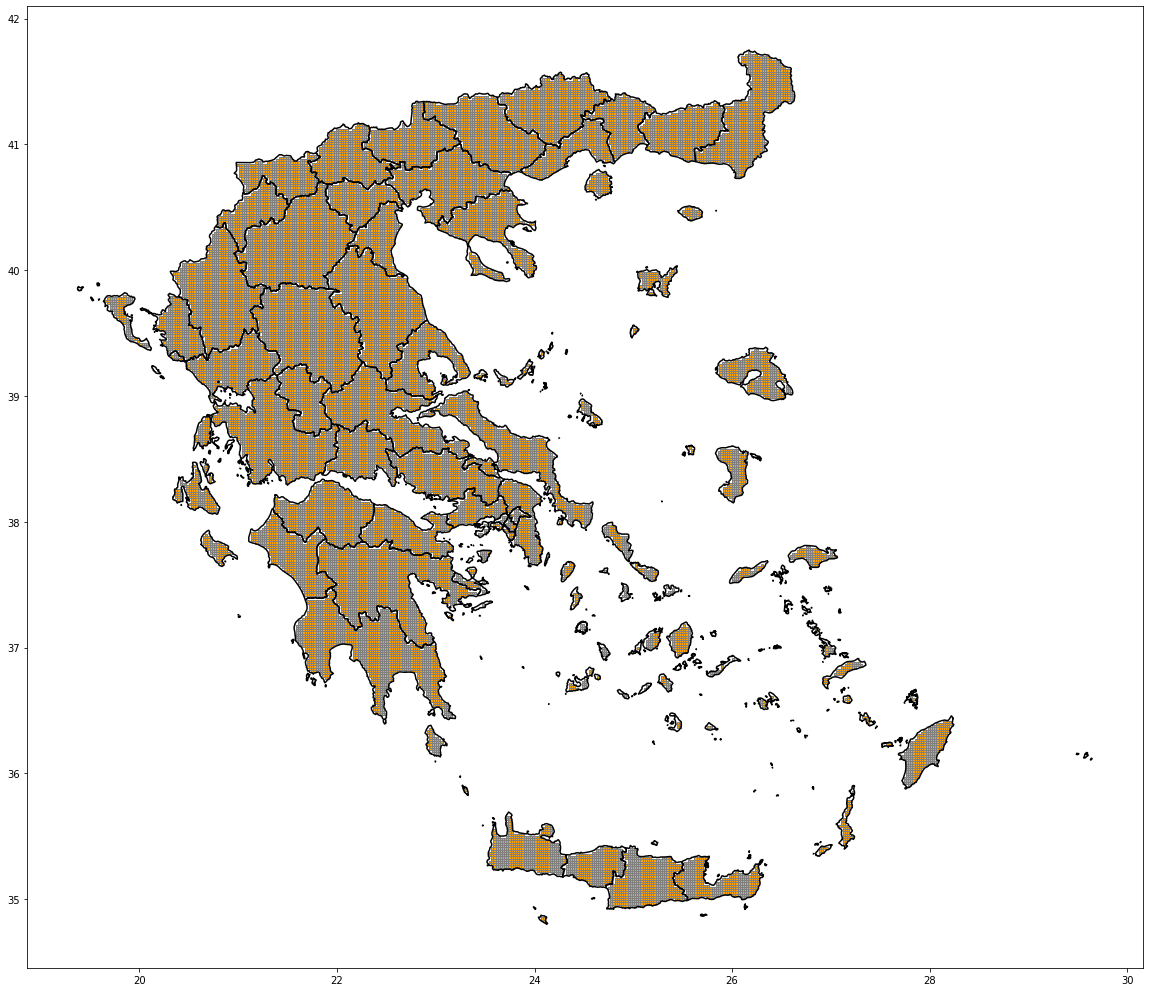

In [13]:
ax = empty_gdf.plot(figsize=(20, 20), cmap='jet', color='blue', lw=1)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')
greece_nuts3.plot(facecolor="none", edgecolor='black', ax=ax, lw=1.5)

In [14]:
df_grid.rename(columns={"NAME": "NUTS_NAME"}, inplace = True)

In [15]:
df_grid_el3 = pd.merge(df_grid, greece_nuts3.drop(columns=('geometry')), how='left', on=['NUTS_NAME'])

In [16]:
df_grid_el3

,geometry,centers,NUTS_NAME,x,y,NUTS_ID,CNTR_CODE,NAME_LATN,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,CNTR_NAME
0,"POLYGON ((24.76634 35.08232, 24.76634 35.10029...",POINT (24.75538506876156 35.091307570202034),Ηράκλειο,24.75539,35.09131,EL431,EL,Irakleio,2.0,2,1,Greece
1,"POLYGON ((24.78825 34.93859, 24.78825 34.95656...",POINT (24.777297114602607 34.947574037400315),Ηράκλειο,24.77730,34.94757,EL431,EL,Irakleio,2.0,2,1,Greece
2,"POLYGON ((24.78825 34.95656, 24.78825 34.97452...",POINT (24.777297114602607 34.96554072900054),Ηράκλειο,24.77730,34.96554,EL431,EL,Irakleio,2.0,2,1,Greece
3,"POLYGON ((24.78825 34.97452, 24.78825 34.99249...",POINT (24.777297114602607 34.98350742060075),Ηράκλειο,24.77730,34.98351,EL431,EL,Irakleio,2.0,2,1,Greece
4,"POLYGON ((24.78825 34.99249, 24.78825 35.01046...",POINT (24.777297114602607 35.00147411220097),Ηράκλειο,24.77730,35.00147,EL431,EL,Irakleio,2.0,2,1,Greece
...,...,...,...,...,...,...,...,...,...,...,...,...
27520,"POLYGON ((23.29621 38.59082, 23.29621 38.60879...",POINT (23.284728352824448 38.59980280380118),Φθιώτιδα,23.28473,38.59980,EL644,EL,Fthiotida,3.0,3,1,Greece
27521,"POLYGON ((23.29621 38.60879, 23.29621 38.62675...",POINT (23.284728352824448 38.61776949540139),Φθιώτιδα,23.28473,38.61777,EL644,EL,Fthiotida,3.0,3,1,Greece
27522,"POLYGON ((23.29621 38.62675, 23.29621 38.64472...",POINT (23.284728352824448 38.635736187001605),Φθιώτιδα,23.28473,38.63574,EL644,EL,Fthiotida,3.0,3,1,Greece
27523,"POLYGON ((23.31917 38.53692, 23.31917 38.55489...",POINT (23.307686122160266 38.54590272900053),Φθιώτιδα,23.30769,38.54590,EL644,EL,Fthiotida,3.0,3,1,Greece


In [18]:
df_grid_el3.drop(columns=('centers')).to_file('../data/EL_Grid_NUTS3_2x2.shp', encoding = 'utf-8')

In [19]:
np.sort(df_grid_el3.NUTS_ID.unique())

array(['EL301', 'EL302', 'EL303', 'EL304', 'EL305', 'EL306', 'EL307',
       'EL411', 'EL412', 'EL413', 'EL421', 'EL422', 'EL431', 'EL432',
       'EL433', 'EL434', 'EL511', 'EL512', 'EL513', 'EL514', 'EL515',
       'EL521', 'EL522', 'EL523', 'EL524', 'EL525', 'EL526', 'EL527',
       'EL531', 'EL532', 'EL533', 'EL541', 'EL542', 'EL543', 'EL611',
       'EL612', 'EL613', 'EL621', 'EL622', 'EL623', 'EL624', 'EL631',
       'EL632', 'EL633', 'EL641', 'EL642', 'EL643', 'EL644', 'EL645',
       'EL651', 'EL652', 'EL653'], dtype=object)